# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales
- Realizar procesamiento de datos aplicado a entender y mejorar los indicadores ICFES en el territorio nacional.
- Integrar conjuntos de datos territoriales, sociales y económicos con los resultados educativos nacionales.
- Realizar exploración y transformación del conjunto global de datos disponible que permita su análisis de forma correcta y sin sesgos.


**Version:** Entrega 1

### Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas
from functools import reduce    # -> Para aplicar reducción de datos (calcular metricas)
import matplotlib.ticker as mticker # -> Para manejo y personalización de graficos

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql import functions as F          # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores  
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones
from pyspark.sql.window import Window           # -> Para calculos acumulados

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation','/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

### Actividades a realizar

- Lectura de data
- Descripción de los datos
- Exploración de los datos
- Reporte de calidad
- Planteamiento de preguntas investigativas
- Limpieza, filtro y transformaciones iniciales

## **Lectura de data**

In [4]:
## Se crea el dataframe para acceder al sistema de fichero csv como un objeto dataframe pyspark
## El acceso se hara desde la carpeta data del proyecto, donde se encuentran las bases de datos seleccionadas
dfPy00 = sparkSigma.read.format("csv").option("header","true").load("../data/MEN_ESTADISTICAS_MATRICULA_POR_MUNICIPIOS_ES_20260407.csv")
dfPy00.show(5)

+----+----------------------+-----------------------+-------------------+--------------------+-------------------+-----------+-------------+---------------+--------+---------+--------------+
| AÑO|Código delDepartamento|Nombre del Departamento|Código delMunicipio|Nombre del Municipio|TECNICA PROFESIONAL|TECNOLOGICA|UNIVERSITARIA|ESPECIALIZACION|MAESTRIA|DOCTORADO|IES CON OFERTA|
+----+----------------------+-----------------------+-------------------+--------------------+-------------------+-----------+-------------+---------------+--------+---------+--------------+
|2005|                    11|                     11|              11001|         BOGOTÁ D.C.|             63,098|     40,178|      279,544|         23,603|   7,399|      492|           106|
|2005|                    13|                     13|              13001| CARTAGENA DE INDIAS|              5,902|      4,348|       25,138|          1,260|       9|        0|            33|
|2005|                    13|                

## **Descripción de los datos**

In [5]:
dfPy00.printSchema()

root
 |-- AÑO: string (nullable = true)
 |-- Código delDepartamento: string (nullable = true)
 |-- Nombre del Departamento: string (nullable = true)
 |-- Código delMunicipio: string (nullable = true)
 |-- Nombre del Municipio: string (nullable = true)
 |-- TECNICA PROFESIONAL: string (nullable = true)
 |-- TECNOLOGICA: string (nullable = true)
 |-- UNIVERSITARIA: string (nullable = true)
 |-- ESPECIALIZACION: string (nullable = true)
 |-- MAESTRIA: string (nullable = true)
 |-- DOCTORADO: string (nullable = true)
 |-- IES CON OFERTA: string (nullable = true)



Este conjunto de datos recopila estadísticas detalladas sobre la matrícula en educación superior en los municipios de Colombia, desglosada por niveles de formación (desde técnica profesional hasta doctorado). Su propósito es monitorear la cobertura y el acceso a la formación avanzada a nivel territorial, así como identificar la presencia física de Instituciones de Educación Superior (IES) en cada región. En el contexto del proyecto, esta información es fundamental para analizar la transición de los estudiantes desde la educación media (ICFES Saber 11) hacia la educación superior, permitiendo correlacionar el desempeño académico con la oferta educativa y las oportunidades de profesionalización disponibles en cada municipio.

## Diccionario de datos

| Nombre de la Variable | Tipo de Dato | Definición | Ejemplo |
| :--- | :--- | :--- | :--- |
| AÑO | **Integer** | Año correspondiente al reporte estadístico de matrícula. | 2005 |
| Código delDepartamento | **String** | Código numérico oficial que identifica al departamento. Se maneja como texto para conservar la integridad de los códigos de dos dígitos. | "13" |
| Nombre del Departamento | **String** | Nombre de la entidad territorial departamental. | "BOLÍVAR" |
| Código delMunicipio | **String** | Código único (DANE) que identifica al municipio. Es la llave principal para cruces de datos geográficos. | "13001" |
| Nombre del Municipio | **String** | Nombre de la entidad territorial municipal. | "CARTAGENA DE INDIAS" |
| TECNICA PROFESIONAL | **Long** | Cantidad de estudiantes matriculados en programas de nivel técnico profesional en el municipio. | 5902 |
| TECNOLOGICA | **Long** | Cantidad de estudiantes matriculados en programas de nivel tecnológico en el municipio. | 4348 |
| UNIVERSITARIA | **Long** | Cantidad de estudiantes matriculados en programas de pregrado universitario en el municipio. | 25138 |
| ESPECIALIZACION | **Long** | Cantidad de estudiantes matriculados en programas de posgrado a nivel de especialización. | 1260 |
| MAESTRIA | **Long** | Cantidad de estudiantes matriculados en programas de posgrado a nivel de maestría. | 9 |
| DOCTORADO | **Long** | Cantidad de estudiantes matriculados en programas de posgrado a nivel de doctorado. | 0 |
| IES CON OFERTA | **Integer** | Número de Instituciones de Educación Superior que cuentan con oferta académica activa en el municipio. | 33 |

In [6]:
## Se cambia el tipo de dato de la base a la estipulada
# VERSION
dfPy01 = dfPy00

from pyspark.sql.functions import col, regexp_replace

# Definimos las columnas que son numéricas y pueden traer comas o puntos de miles
columnas_numericas = [
    "TECNICA PROFESIONAL", "TECNOLOGICA", "UNIVERSITARIA", 
    "ESPECIALIZACION", "MAESTRIA", "DOCTORADO", "IES CON OFERTA"
]

# Aplicamos la limpieza: 
# 1. regexp_replace elimina comas (,) y puntos (.)
# 2. cast transforma a tipo numérico (Long para matrículas, Int para IES)

df_limpio = dfPy01

for columna in columnas_numericas:
    # Eliminamos cualquier caracter que no sea un número (comas y puntos)
    df_limpio = df_limpio.withColumn(
        columna, 
        regexp_replace(col(columna), r"[,.]", "").cast("long")
    )

# El año y los códigos se mantienen como string o int según corresponda
dfPy01 = df_limpio.withColumn("AÑO", col("AÑO").cast("int")) \
    .withColumn("Código delDepartamento", col("Código delDepartamento").cast("string")) \
    .withColumn("Código delMunicipio", col("Código delMunicipio").cast("string"))

# Verificamos que el cambio se haya hecho correctamente
dfPy01.select("Nombre del Municipio", "UNIVERSITARIA", "IES CON OFERTA").show(5)
dfPy01.printSchema()

+--------------------+-------------+--------------+
|Nombre del Municipio|UNIVERSITARIA|IES CON OFERTA|
+--------------------+-------------+--------------+
|         BOGOTÁ D.C.|       279544|           106|
| CARTAGENA DE INDIAS|        25138|            33|
|    BARRANCO DE LOBA|            0|             1|
|              CICUCO|            0|             1|
|            EL GUAMO|            0|             1|
+--------------------+-------------+--------------+
only showing top 5 rows

root
 |-- AÑO: integer (nullable = true)
 |-- Código delDepartamento: string (nullable = true)
 |-- Nombre del Departamento: string (nullable = true)
 |-- Código delMunicipio: string (nullable = true)
 |-- Nombre del Municipio: string (nullable = true)
 |-- TECNICA PROFESIONAL: long (nullable = true)
 |-- TECNOLOGICA: long (nullable = true)
 |-- UNIVERSITARIA: long (nullable = true)
 |-- ESPECIALIZACION: long (nullable = true)
 |-- MAESTRIA: long (nullable = true)
 |-- DOCTORADO: long (nullable = true)

## **Exploración de los datos**

In [7]:
stats = []
for col in columnas_numericas:
    row = dfPy01.select(
        F.lit(col).alias("Variable"),
        F.count(F.col(col)).alias("Count"),
        F.round(F.mean(F.col(col)), 2).alias("Media"),
        F.round(F.stddev(F.col(col)), 2).alias("Std"),
        F.round(F.min(F.col(col)), 2).alias("Min"),
        F.round(F.percentile_approx(F.col(col), 0.25), 2).alias("P25"),
        F.round(F.percentile_approx(F.col(col), 0.50), 2).alias("Mediana"),
        F.round(F.percentile_approx(F.col(col), 0.75), 2).alias("P75"),
        F.round(F.max(F.col(col)), 4).alias("Max"),
    )
    stats.append(row)

df_stats = reduce(lambda a, b: a.union(b), stats)
df_stats.show(len(columnas_numericas), truncate=False)

+-------------------+-----+-------+--------+---+---+-------+---+-------+
|Variable           |Count|Media  |Std     |Min|P25|Mediana|P75|Max    |
+-------------------+-----+-------+--------+---+---+-------+---+-------+
|TECNICA PROFESIONAL|19618|187.51 |2034.95 |0  |0  |0      |37 |72772  |
|TECNOLOGICA        |19618|913.93 |14500.15|0  |0  |31     |117|1295165|
|UNIVERSITARIA      |19618|2482.52|42773.25|0  |0  |1      |72 |3815393|
|ESPECIALIZACION    |19618|130.97 |1584.72 |0  |0  |0      |0  |56147  |
|MAESTRIA           |19618|68.02  |863.55  |0  |0  |0      |0  |31302  |
|DOCTORADO          |19618|6.43   |85.38   |0  |0  |0      |0  |2410   |
|IES CON OFERTA     |19618|2.79   |6.38    |1  |1  |1      |2  |133    |
+-------------------+-----+-------+--------+---+---+-------+---+-------+



Puntos importantes a tener en cuenta con base en los resultados:
1) Se evidencia una centralización extrema de la educación superior, ya que la diferencia entre la Media y la Mediana en todas las variables es muy grande, indicando asimetrías positivas, que se refiere en el contexto a que pocos municipios concentran la gran mayoría de matriculados mientras la mayoría de municipios tienen muy pocos.
2) Ausencia de estudios de posgrado en toda la nación, pues al ver el percentil 75 de las maestrías, doctorados y especializaciones, se tiene 0. Lo que indica que al menos el 75% de los registros no tiene ninguna persona estudiando algún posgrado
3) En general, en el país se estudia más en tecnólogos, pero en las grandes ciudades, se opta más por pregrados
4) Instituciones de educación superior agrupadas en unos pocos municipios (P75=2, Max=133)

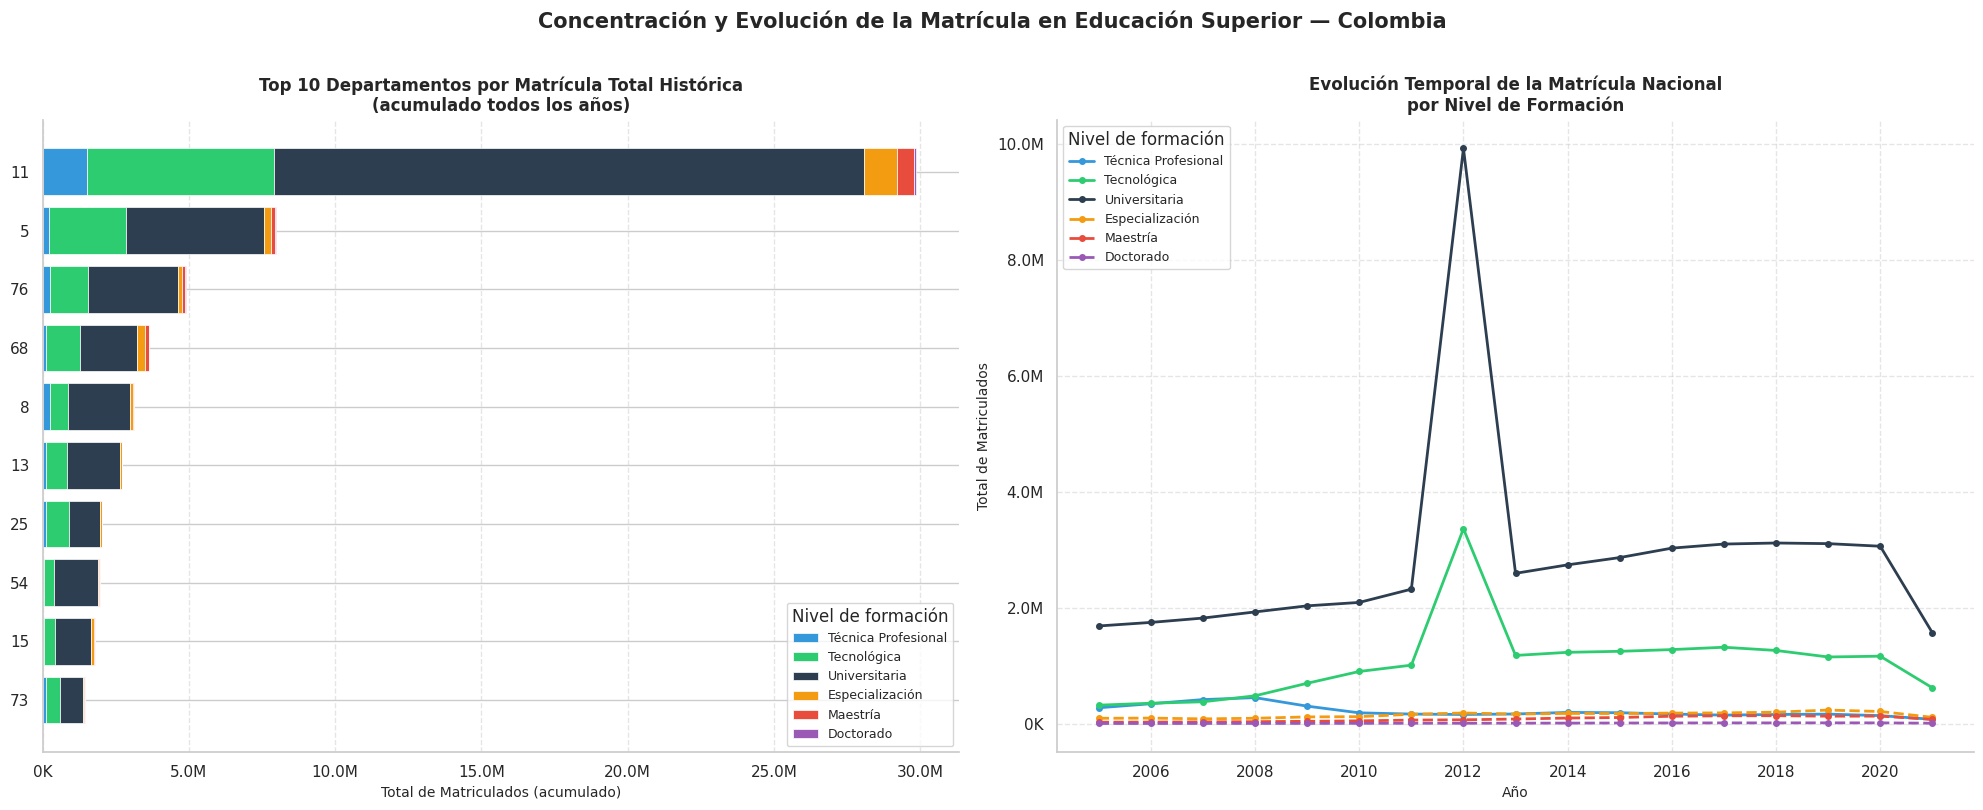

In [8]:
#### Concentración de matrícula por departamento y nivel de formación (Top 10)
# Agrupamos por departamento sumando todos los años
df_depto = (
    dfPy01.groupBy("Nombre del Departamento")
    .agg(
        F.sum(F.col("`TECNICA PROFESIONAL`")).alias("Técnica Profesional"),
        F.sum(F.col("TECNOLOGICA")).alias("Tecnológica"),
        F.sum(F.col("UNIVERSITARIA")).alias("Universitaria"),
        F.sum(F.col("ESPECIALIZACION")).alias("Especialización"),
        F.sum(F.col("MAESTRIA")).alias("Maestría"),
        F.sum(F.col("DOCTORADO")).alias("Doctorado"),
    )
    .withColumn(
        "TOTAL",
        F.col("Técnica Profesional") + F.col("Tecnológica") + F.col("Universitaria")
        + F.col("Especialización") + F.col("Maestría") + F.col("Doctorado")
    )
    .orderBy(F.col("TOTAL").desc())
    .limit(10)
    .toPandas()
)

# Evolución temporal de matrícula nacional por nivel
df_temporal = (
    dfPy01.groupBy("AÑO")
    .agg(
        F.sum(F.col("`TECNICA PROFESIONAL`")).alias("Técnica Profesional"),
        F.sum(F.col("TECNOLOGICA")).alias("Tecnológica"),
        F.sum(F.col("UNIVERSITARIA")).alias("Universitaria"),
        F.sum(F.col("ESPECIALIZACION")).alias("Especialización"),
        F.sum(F.col("MAESTRIA")).alias("Maestría"),
        F.sum(F.col("DOCTORADO")).alias("Doctorado"),
    )
    .orderBy("AÑO")
    .toPandas()
)

# ── Paleta y estilos ────────────────────────────────────────────────────
colores_nivel = {
    "Técnica Profesional": "#3498DB",
    "Tecnológica":         "#2ECC71",
    "Universitaria":       "#2C3E50",
    "Especialización":     "#F39C12",
    "Maestría":            "#E74C3C",
    "Doctorado":           "#9B59B6",
}
niveles = list(colores_nivel.keys())

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    "Concentración y Evolución de la Matrícula en Educación Superior — Colombia",
    fontsize=15, fontweight="bold", y=1.01
)

# ── Gráfica 1: Stacked bar horizontal — Top 10 departamentos ────────────
ax1 = axes[0]
df_depto_sorted = df_depto.sort_values("TOTAL", ascending=True)
left = [0] * len(df_depto_sorted)

for nivel in niveles:
    valores = df_depto_sorted[nivel].fillna(0).values
    bars = ax1.barh(
        df_depto_sorted["Nombre del Departamento"],
        valores,
        left=left,
        color=colores_nivel[nivel],
        label=nivel,
        edgecolor="white",
        linewidth=0.5,
    )
    left = [l + v for l, v in zip(left, valores)]

ax1.set_title("Top 10 Departamentos por Matrícula Total Histórica\n(acumulado todos los años)", fontsize=12, fontweight="bold")
ax1.set_xlabel("Total de Matriculados (acumulado)", fontsize=10)
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax1.legend(loc="lower right", fontsize=9, title="Nivel de formación")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(True, axis="x", linestyle="--", alpha=0.5)

# ── Gráfica 2: Evolución temporal por nivel ─────────────────────────────
ax2 = axes[1]
for nivel in niveles:
    ax2.plot(
        df_temporal["AÑO"],
        df_temporal[nivel],
        marker="o",
        linewidth=2,
        markersize=4,
        label=nivel,
        color=colores_nivel[nivel],
        linestyle="--" if nivel in ("Especialización", "Maestría", "Doctorado") else "-",
    )

ax2.set_title("Evolución Temporal de la Matrícula Nacional\npor Nivel de Formación", fontsize=12, fontweight="bold")
ax2.set_xlabel("Año", fontsize=10)
ax2.set_ylabel("Total de Matriculados", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9, loc="upper left", title="Nivel de formación")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Las dos gráficas anteriores confirman y enriquecen los hallazgos estadísticos iniciales:

1. **Centralización extrema (Gráfica 1):** Bogotá D.C. concentra un volumen de matrícula que supera en varias veces al del segundo departamento (Antioquia), lo cual es coherente con la gran diferencia entre la Media y la Mediana observada en los estadísticos. Los 10 departamentos con mayor matrícula reúnen la abrumadora mayoría de los matriculados a nivel nacional, evidenciando una profunda desigualdad territorial en el acceso a la educación superior.

2. **Dominio del nivel universitario:** En todos los departamentos del Top 10, la franja de *Universitaria* (color azul oscuro) es la más amplia, ratificando que el pregrado universitario es el nivel de formación predominante en los grandes centros urbanos, mientras que los niveles de posgrado (Especialización, Maestría y Doctorado) son prácticamente imperceptibles en la escala acumulada.

3. **Crecimiento sostenido con aceleración reciente (Gráfica 2):** La matrícula universitaria muestra un crecimiento continuo desde 2005, con una aceleración notable a partir de 2012, posiblemente relacionada con políticas de acceso a la educación superior (como *Ser Pilo Paga*). La pandemia de 2020 no generó una caída abrupta, sino una ligera desaceleración seguida de recuperación.

## **Reporte de calidad**

In [9]:
# Mostrar porcentaje de nulos por columna
total_filas = dfPy01.count()

nulos = dfPy01.select(
    *[
        F.round(
            (F.sum(F.col(f"`{c}`").isNull().cast("int")) / total_filas) * 100, 2  # <-- backticks aquí
        ).alias(c)
        for c in dfPy01.columns
    ]
)

# Transponer para mejor legibilidad
nulos_rows = []
for c in dfPy01.columns:
    nulos_rows.append(
        nulos.select(
            F.lit(c).alias("Variable"),
            F.col(f"`{c}`").alias("% Nulos"),
        )
    )

df_nulos = reduce(lambda a, b: a.union(b), nulos_rows)
df_nulos.orderBy(
    F.col("% Nulos").desc()
).show(truncate=False)

+-----------------------+-------+
|Variable               |% Nulos|
+-----------------------+-------+
|Código delMunicipio    |0.0    |
|TECNOLOGICA            |0.0    |
|UNIVERSITARIA          |0.0    |
|AÑO                    |0.0    |
|Nombre del Departamento|0.0    |
|ESPECIALIZACION        |0.0    |
|IES CON OFERTA         |0.0    |
|TECNICA PROFESIONAL    |0.0    |
|MAESTRIA               |0.0    |
|DOCTORADO              |0.0    |
|Código delDepartamento |0.0    |
|Nombre del Municipio   |0.0    |
+-----------------------+-------+



In [10]:
# Columnas numéricas a revisar para análisis de nulos
columnas_revisar = columnas_numericas  # Todas las columnas numéricas del dataset

# Contar cantidad de filas con al menos un nulo
filas_con_nulo = dfPy01.filter(
    F.greatest(*[F.col(f"`{c}`").isNull().cast("int") for c in columnas_revisar]) == 1
).count()

print("=" * 50)
print(f"  Total de filas:               {total_filas:,}")
print(f"  Filas con al menos un nulo:   {filas_con_nulo:,}")
print(f"  Porcentaje:                   {filas_con_nulo / total_filas * 100:.2f}%")
print("=" * 50)

  Total de filas:               19,618
  Filas con al menos un nulo:   0
  Porcentaje:                   0.00%


In [11]:
## Para contar cuantas filas tienen x cantidad de variables nulas
# Contar cuántos nulos tiene cada fila
df_conteo_nulos = dfPy01.withColumn(
    "cantidad_nulos",
    sum([F.col(f"`{c}`").isNull().cast("int") for c in columnas_revisar])
)

# Ventana acumulada ordenada por cantidad de nulos
ventana_acumulada = Window.orderBy("cantidad_nulos").rowsBetween(
    Window.unboundedPreceding, Window.currentRow
)

# Agrupar y calcular porcentaje simple y acumulado
df_distribucion = (
    df_conteo_nulos
    .groupBy("cantidad_nulos")
    .count()
    .orderBy("cantidad_nulos")
    .withColumnRenamed("count", "cantidad_filas")
    .withColumn(
        "porcentaje",
        F.round(F.col("cantidad_filas") / total_filas * 100, 2)
    )
    .withColumn(
        "porcentaje_acumulado",
        F.round(F.sum("cantidad_filas").over(ventana_acumulada) / total_filas * 100, 2)
    )
)

df_distribucion.show(truncate=False)

+--------------+--------------+----------+--------------------+
|cantidad_nulos|cantidad_filas|porcentaje|porcentaje_acumulado|
+--------------+--------------+----------+--------------------+
|0             |19618         |100.0     |100.0               |
+--------------+--------------+----------+--------------------+



A diferencia de otros conjuntos de datos del proyecto, este dataset **no presenta columnas con nulos**, por lo que no es necesario realizar plan de manejo de valores faltantes.

## **Planteamiento de preguntas investigativas**

1. ¿Existe una relación entre la concentración de matrícula en educación superior de un departamento y el puntaje promedio obtenido en las pruebas Saber 11 por sus estudiantes?
2. ¿Los municipios con mayor presencia de Instituciones de Educación Superior (IES) presentan mejores resultados en las pruebas ICFES?
3. ¿Cómo ha evolucionado la brecha de matrícula entre los departamentos con mayor y menor oferta educativa a lo largo del período analizado, y qué relación guarda con el desempeño en el ICFES?

## **Limpieza, filtro y transformaciones iniciales**

Dada la naturaleza del dataset, no se plantean limpieza, filtro ni transformaciones iniciales del conjunto de datos